In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification and Regressation
from xgboost import XGBClassifier, XGBRegressor

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import classification_report

#Model saving
import pickle

## Loading Data

In [ ]:
# loading data set

In [ ]:
# accepeted dataset
df1 = pd.read_csv('/content/sample_data/accepted_loan.csv')

/tmp/ipykernel_24144/1707521318.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('/content/sample_data/accepted_loan.csv')


In [ ]:
df1.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df1['emp_length']

,emp_length
0,10+ years
1,10+ years
2,10+ years
3,10+ years
4,3 years
...,...
15418,9 years
15419,6 years
15420,2 years
15421,NaN


In [ ]:
# rejected dataset
df2 = pd.read_csv('/content/sample_data/rejected_loan.csv')

In [ ]:
df2.head()

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0


In [ ]:
# Taking colums present in both dataset
feature_acc = [
    'loan_amnt',
    'fico_range_low',
    'fico_range_high',
    'dti',
    'addr_state',
    'emp_length'
]

df_acc = df1[feature_acc]

feature_rej =  [
    'Amount Requested',
    'Risk_Score',
    'Debt-To-Income Ratio',
    'State',
    'Employment Length'
]

df_rej = df2[feature_rej]

## Data Cleaning

In [ ]:
# Creating a function to combine both data
def combine_data(df_acc,def_rej):
  # accepeted data
  accepted = pd.DataFrame({
      'amount': df_acc['loan_amnt'],
      'risk_score': (df_acc['fico_range_low'] + df_acc['fico_range_low'])/2, # new feature
      'dti': df_acc['dti'],
      'state': df_acc['addr_state'],
      'emp_length': df_acc['emp_length'],
      'loan_status': 1
  })

  rejected = pd.DataFrame({
      'amount': df_rej['Amount Requested'],
      'risk_score': df_rej['Risk_Score'],
      'dti': df_rej['Debt-To-Income Ratio'].str.replace('%', '').astype(float),
      'state': df_rej['State'],
      'emp_length': df_rej['Employment Length'],
      'loan_status': 0
  })


  acc_rej_dt = pd.concat([accepted,rejected],axis=0).dropna()
  acc_rej_dt.drop_duplicates(inplace=True)
  return acc_rej_dt

In [ ]:
df_acc_rej  =  combine_data(df_acc,df_rej)

In [ ]:
df_acc_rej.head(100)

,amount,risk_score,dti,state,emp_length,loan_status
0,3600.0,675.0,5.91,PA,10+ years,1
1,24700.0,715.0,16.06,SD,10+ years,1
2,20000.0,695.0,10.78,IL,10+ years,1
3,35000.0,785.0,17.06,NJ,10+ years,1
4,10400.0,695.0,25.37,PA,3 years,1
...,...,...,...,...,...,...
98,3600.0,675.0,17.44,VA,< 1 year,1
99,7200.0,705.0,13.21,MA,9 years,1
100,15000.0,670.0,18.17,FL,4 years,1
101,5000.0,710.0,6.52,NC,6 years,1


In [ ]:
df_acc_rej['state'].value_counts()

,count
state,
CA,55646
TX,34632
NY,32719
FL,31898
PA,19445
IL,18218
OH,16426
GA,16002
NJ,15727


In [ ]:
df_acc_rej.info()

<class 'pandas.core.frame.DataFrame'>
Index: 423060 entries, 0 to 461125
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   amount       423060 non-null  float64
 1   risk_score   423060 non-null  float64
 2   dti          423060 non-null  float64
 3   state        423060 non-null  object 
 4   emp_length   423060 non-null  object 
 5   loan_status  423060 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 22.6+ MB


In [ ]:
def clean_data(df):

  df['dti'] = df['dti'].astype(str)
  # extracting number
  df['dti'] = df['dti'].str.extract(r'(\d+)')
  df['dti'] = df['dti'].astype(float)



  df['emp_length'] = (
        df['emp_length']
        .astype(str)
        .str.extract(r'(\d+)')[0]
        .astype(float)
    )

  # lot of state need to handel
  top_states = df['state'].value_counts().nlargest(10).index
  df['state'] = df['state'].apply(lambda x: x if x in top_states else 'Other')

  return df

In [ ]:
clean_dataset_acc_rej = clean_data(df_acc_rej)
clean_dataset_acc_rej.head()

,amount,risk_score,dti,state,emp_length,loan_status
0,3600.0,675.0,5.0,PA,10.0,1
1,24700.0,715.0,16.0,Other,10.0,1
2,20000.0,695.0,10.0,IL,10.0,1
3,35000.0,785.0,17.0,NJ,10.0,1
4,10400.0,695.0,25.0,PA,3.0,1


In [ ]:
clean_dataset_acc_rej.info()

<class 'pandas.core.frame.DataFrame'>
Index: 423060 entries, 0 to 461125
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   amount       423060 non-null  float64
 1   risk_score   423060 non-null  float64
 2   dti          423060 non-null  float64
 3   state        423060 non-null  object 
 4   emp_length   423060 non-null  float64
 5   loan_status  423060 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 22.6+ MB


In [ ]:
clean_dataset_acc_rej['state'].unique()

array(['PA', 'Other', 'IL', 'NJ', 'GA', 'TX', 'CA', 'VA', 'NY', 'OH',
       'FL'], dtype=object)

## Preprocessing

In [ ]:
# Label encoding
le = LabelEncoder()
clean_dataset_acc_rej['state'] = le.fit_transform(clean_dataset_acc_rej['state'])

In [ ]:
clean_dataset_acc_rej.head()

,amount,risk_score,dti,state,emp_length,loan_status
0,3600.0,675.0,5.0,8,10.0,1
1,24700.0,715.0,16.0,7,10.0,1
2,20000.0,695.0,10.0,3,10.0,1
3,35000.0,785.0,17.0,4,10.0,1
4,10400.0,695.0,25.0,8,3.0,1


In [ ]:
clean_dataset_acc_rej.to_csv('accept_reject_clean_dataset.csv',index=False)

## EDA

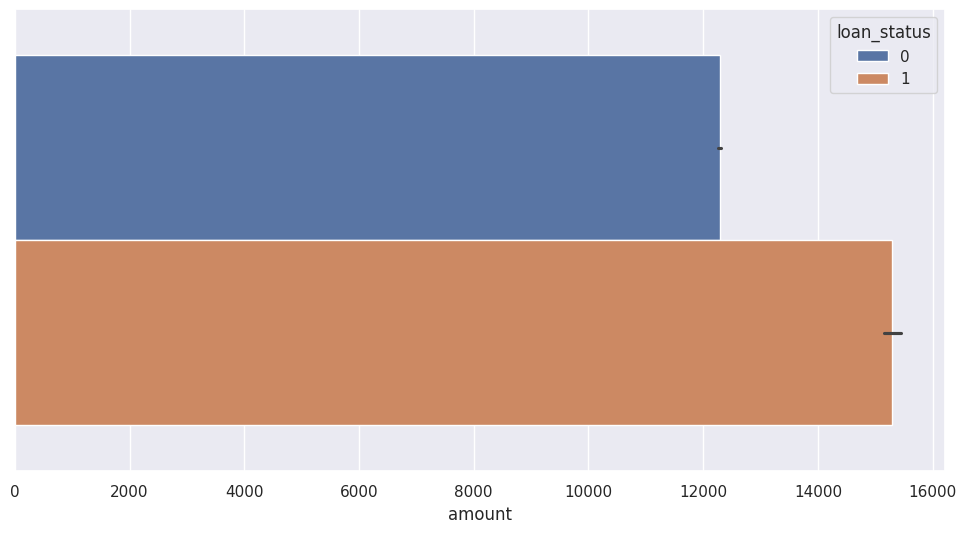

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x = 'amount',data = clean_dataset_acc_rej,hue='loan_status')
plt.show()

<Axes: xlabel='risk_score', ylabel='Count'>

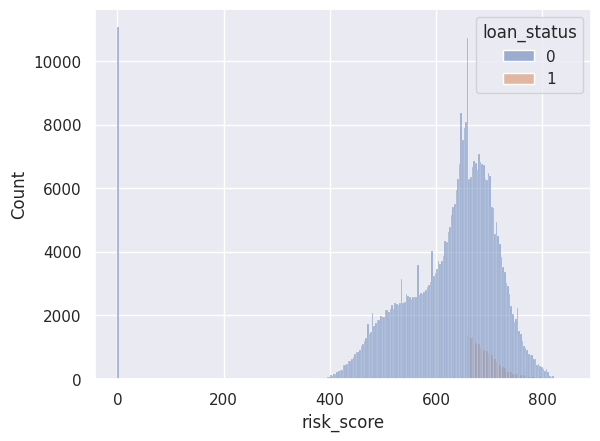

In [ ]:
sns.histplot(x = 'risk_score',data = clean_dataset_acc_rej,hue='loan_status')

## Model Building

In [ ]:
#feature selecting
X = clean_dataset_acc_rej.drop('loan_status', axis=1)
y = clean_dataset_acc_rej['loan_status']

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Classification

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:16:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#Regression for predicting amount

df_acc_reg = clean_dataset_acc_rej[clean_dataset_acc_rej['loan_status'] == 1]
X_reg = df_acc_reg[['risk_score', 'dti', 'state', 'emp_length']]
y_reg = df_acc_reg['amount']

amt_reg = XGBRegressor()
amt_reg.fit(X_reg, y_reg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Clustering

kmeans = KMeans(n_clusters=4, random_state=42)
clean_dataset_acc_rej['segment'] = kmeans.fit_predict(X_scaled)

In [ ]:
#Model Evaluating

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     81726
           1       0.70      0.60      0.65      2886

    accuracy                           0.98     84612
   macro avg       0.84      0.80      0.82     84612
weighted avg       0.98      0.98      0.98     84612



In [ ]:
# Create a mapping that handles unknown states by defaulting to a 'Global' average
state_mapping = {label: i for i, label in enumerate(le.classes_)}
default_state_val = int(len(le.classes_) / 2) # A middle-ground index

artifacts = {
    'classifier': clf,
    'regressor': amt_reg,
    'scaler': scaler,
    'state_mapping': state_mapping, # Save the dict instead of the LE object
    'default_state': default_state_val
}

In [ ]:
with open('lending_club_pipeline.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Pipeline Saved Successfully.")

Pipeline Saved Successfully.
